In [1]:
from google.colab import drive

drive.mount('/content/drive')

KeyboardInterrupt: 

# CNN - extract features

Pre-process image

In [2]:
!pip install pydicom

In [3]:
import numpy as np
import pydicom
import matplotlib.pyplot as plt

In [4]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold, KFold, StratifiedKFold
import seaborn as sns
import math
import cv2
import pydicom
import os
from tqdm import tqdm
import glob
import pickle as pkl
import matplotlib.image as mpimg
from tabulate import tabulate
import missingno as msno
from IPython.display import display_html
from PIL import Image
import gc
from skimage.transform import resize
import copy
import re
from scipy.stats import pearsonr

# Segmentation
import glob
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import scipy.ndimage
from skimage import morphology
from skimage import measure
from skimage.transform import resize
from sklearn.cluster import KMeans
from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from plotly.tools import FigureFactory as FF
from plotly.graph_objs import *
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings("ignore")

#------------------------------------------------------------

pd.set_option("display.max_columns", 100)

#Define resolution of image 512*512
N_ROWS = 512
N_COLS = 512
path = 'C:/Users/frank/OneDrive/Desktop/Thesis - Progress Prediction/CodeDevelopment/osic-pulmonary-fibrosis-progression/'
#Define Batch size
BATCH_SIZE=128

# Areas with the same number of pixels on the edges are not required. Crop it.
def crop_image(img: np.ndarray):
    edge_pixel_value = img[0, 0]
    mask = img != edge_pixel_value
    return img[np.ix_(mask.any(1),mask.any(0))]

# Load images, crop thick borders(if any) and resize
def load_image(path):
    dataset = pydicom.dcmread(path)
    img = dataset.pixel_array
    img = crop_image(img)
#   img = cv2.resize(img, (512,512))
    return img

# Get Nth percentile image
def get_img(perc, patient_id, data):

    l = glob.glob(path+'{0}/{1}/*.dcm'.format(data, patient_id))
    img_ids = []
    for x in l:
        y = x.split('\\')[-1]
        z = int(y.split('.')[0])
        img_ids.append(z)

    img_ids.sort()

    return img_ids[math.ceil(perc*(len(img_ids)))-1]

# Get num of slices bw two percentiles
def num_img_bw_perc(p1, p2, patient_id, data):

    l = glob.glob(path+'{0}/{1}/*.dcm'.format(data, patient_id))
    img_ids = []
    for x in l:
        y = x.split('\\')[-1]
        z = int(y.split('.')[0])
        img_ids.append(z)

    img_ids.sort()

    return len(img_ids[math.ceil(p1*(len(img_ids)))-1:math.ceil(p2*(len(img_ids)))])-1


# Get number of images per patient
def get_num_images(patient_id, data):

    return len(glob.glob(path+'{0}/{1}/*.dcm'.format(data, patient_id)))

# Get the lung area in the image slice
def lung_seg_pixel_ratio(img_array):

    c = 0
    for i in range(img_array.shape[0]):
        for j in range(img_array.shape[1]):
            if img_array[i][j] != 0:
                c+=1

    return c, round(c/(img_array.shape[0]*img_array.shape[1]),4)

# Get dicom meta data
def get_dicom_meta(path):

    '''Get information from the .dcm files.
    path: complete path to the .dcm file'''

    image_data = pydicom.dcmread(path)

    # Dictionary to store the information from the image
    observation_data = {
        "SliceThickness" : float(image_data.SliceThickness),
        "PixelSpacing" : float(image_data.PixelSpacing[0]),
    }

    return observation_data

# Get tissue mask
# To extract the tissues from the segmented lung all we need to do is get rid of the border parts from the segmented lung
# Grey pixels present within the border of the lung is assumed to be tissue.
# Inorder to get rid of the border pixels of the lung we slightly perturb the segmented lung to the right, left, top and bottom
# The intersection of all the perturbed images gets rid of the border lung pixels
# This resultant image serves as the mask for the tissue segmentation
def tissue_mask(img, mask, shift_perc):

    r_dim, c_dim = img.shape[0], img.shape[1]

    # Move the image by shift_perc to the left
    del_left_cols = int(shift_perc*c_dim)

    mask1, mask2 = mask.copy(), np.zeros((r_dim, c_dim)).astype(int)
    mask1 = mask1[:,del_left_cols:]
    mask2[:,:c_dim-del_left_cols] = mask1

    # Move the image by shift_perc to the right
    del_right_cols = int(shift_perc*c_dim)

    mask3, mask4 = mask.copy(), np.zeros((r_dim, c_dim)).astype(int)
    mask3 = mask3[:,:c_dim-del_right_cols]
    mask4[:,del_right_cols:] = mask3

    # Move the image by shift_perc to the top
    del_top_rows = int(shift_perc*c_dim) #BUG C_DIM SHOULD BE R_DIM

    mask5, mask6 = mask.copy(), np.zeros((r_dim, c_dim)).astype(int)
    mask5 = mask5[del_top_rows:,:]
    mask6[:r_dim-del_top_rows,:] = mask5

    # Move the image by shift_perc to the bottom
    del_bottom_rows = int(shift_perc*r_dim)

    mask7, mask8 = mask.copy(), np.zeros((r_dim, c_dim)).astype(int)
    mask7 = mask7[:r_dim-del_bottom_rows,:]
    mask8[del_bottom_rows:,:] = mask7

    #Obtain the final mask
    final_mask = ((mask2==1) & (mask4==1) & (mask6==1) & (mask8==1)).astype(int)

    return final_mask

# Get tissue features
def tissue_features(tissue_mask, img, thresh = 0.35):

    final_img = tissue_mask*img

    checker = np.zeros((final_img.shape[0], final_img.shape[1]))
    counter, other_counter = 0, 0
    for i in range(final_img.shape[0]):
        for j in range(final_img.shape[1]):
            if final_img[i][j]>=thresh:
                checker[i][j] = 1
                counter+=1
            else:
                checker[i][j] = 0
                other_counter+=1

    tissue_by_total = counter/(final_img.shape[0]**2)
    tissue_by_lung = counter/((tissue_mask==1).sum())

    return counter, tissue_by_total, tissue_by_lung, checker

# https://www.raddq.com/dicom-processing-segmentation-visualization-in-python/
def make_lungmask(img, display=False):

    img = img.astype(float)
    row_size= img.shape[0]
    col_size = img.shape[1]


    #Normalize image pixels
    mean = np.mean(img)
    std = np.std(img)
    img = img-mean
    img = img/std

    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size/5):int(col_size/5*4),int(row_size/5):int(row_size/5*4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)

    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img==max]=mean
    img[img==min]=mean
    #Substitutes too light/dark pixels with mean
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    kmeans = KMeans(n_clusters=2).fit(np.reshape(middle,[np.prod(middle.shape),1]))
    centers = sorted(kmeans.cluster_centers_.flatten())
    threshold = np.mean(centers)
    thresh_img = np.where(img<threshold,1.0,0.0)  # threshold the image

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img,np.ones([3,3]))
    dilation = morphology.dilation(eroded,np.ones([8,8]))

    labels = measure.label(dilation) # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if ((B[2]-B[0]<row_size*0.9) and (B[3]-B[1]<col_size*0.9) and (B[2]-B[0]>row_size*0.20)
            and (B[3]-B[1]>col_size*0.10) and (B[0]>row_size*0.03) and (B[2]<row_size*0.97)
            and (B[1]>col_size*0.03) and (B[3]<col_size*0.97)):
            good_labels.append(prop.label)
    mask = np.ndarray([row_size,col_size],dtype=np.int8)
    mask[:] = 0

    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask

    for N in good_labels:
        mask = mask + np.where(labels==N,1,0)
    mask = morphology.dilation(mask,np.ones([10,10])) # one last dilation
 # Compute Lung Area in the slice
    lung_pixels, slice_lung_area = lung_seg_pixel_ratio(mask)

    # Tissue Mask
    t_mask = tissue_mask(img, mask, shift_perc = 0.02)

    # Extract tissue features
    num_t_pixels, tissue_by_total, tissue_by_lung, checker = tissue_features(t_mask, img, thresh = 0.35)

    if (display):
        fig, ax = plt.subplots(4, 2, figsize=[18, 18])
        ax[0, 0].set_title("Original")
        ax[0, 0].imshow(img, cmap='gray')
        ax[0, 0].axis('off')
        ax[0, 1].set_title("Threshold")
        ax[0, 1].imshow(thresh_img, cmap='gray')
        ax[0, 1].axis('off')
        ax[1, 0].set_title("After Erosion and Dilation")
        ax[1, 0].imshow(dilation, cmap='gray')
        ax[1, 0].axis('off')
        ax[1, 1].set_title("Color Labels")
        ax[1, 1].imshow(labels)
        ax[1, 1].axis('off')
        ax[2, 0].set_title("Final Mask")
        ax[2, 0].imshow(mask, cmap='gray')
        ax[2, 0].axis('off')
        ax[2, 1].set_title("Apply Mask on Original")
        ax[2, 1].imshow(mask*img, cmap='gray')
        ax[2, 1].axis('off')
        ax[3, 0].set_title("Inner Lung Mask")
        ax[3, 0].imshow(t_mask, cmap='gray')
        ax[3, 0].axis('off')
        ax[3, 1].set_title("Segmented Tissue")
        ax[3, 1].imshow(checker, cmap='gray')
        ax[3, 1].axis('off')

        plt.show()

    return img,thresh_img,dilation,labels,mask,mask*img,t_mask,checker




Training

In [5]:
csv_path = '/content/drive/MyDrive/Training Survival Analysis/patient_event_slice.csv'
df = pd.read_csv(csv_path)
print(df.head())

                     Patient  event  time  \
0  ID00007637202177411956430      1    11   
1  ID00009637202177434476278      1    52   
2  ID00010637202177584971671      1     5   
3  ID00011637202177653955184      0    52   
4  ID00012637202177665765362      1    54   

                                         slice_files  
0  ['18.dcm', '19.dcm', '2.dcm', '20.dcm', '21.dc...  
1  ['205.dcm', '216.dcm', '226.dcm', '237.dcm', '...  
2  ['32.dcm', '35.dcm', '38.dcm', '40.dcm', '43.d...  
3  ['18.dcm', '19.dcm', '2.dcm', '20.dcm', '21.dc...  
4  ['22.dcm', '24.dcm', '25.dcm', '27.dcm', '28.d...  


In [6]:
import ast
df['slice_files'] = df['slice_files'].apply(ast.literal_eval)


In [7]:
from sklearn.model_selection import train_test_split

patients = df['Patient'].tolist()

# Split 70/15/15 stratified by event
train_patients, temp_patients = train_test_split(
    patients, test_size=0.3, random_state=42, stratify=df['event']
)

val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42,
    stratify=df.set_index('Patient').loc[temp_patients]['event']
)

train_df = df[df['Patient'].isin(train_patients)].reset_index(drop=True)
val_df   = df[df['Patient'].isin(val_patients)].reset_index(drop=True)
test_df  = df[df['Patient'].isin(test_patients)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train: 123, Val: 26, Test: 27


In [8]:
print(train_df)

                       Patient  event  time  \
0    ID00009637202177434476278      1    52   
1    ID00010637202177584971671      1     5   
2    ID00011637202177653955184      0    52   
3    ID00012637202177665765362      1    54   
4    ID00015637202177877247924      1     9   
..                         ...    ...   ...   
118  ID00419637202311204720264      1    12   
119  ID00421637202311550012437      0    55   
120  ID00422637202311677017371      1    41   
121  ID00423637202312137826377      1     1   
122  ID00426637202313170790466      0    59   

                                           slice_files  
0    [205.dcm, 216.dcm, 226.dcm, 237.dcm, 248.dcm, ...  
1    [32.dcm, 35.dcm, 38.dcm, 40.dcm, 43.dcm, 46.dc...  
2    [18.dcm, 19.dcm, 2.dcm, 20.dcm, 21.dcm, 22.dcm...  
3    [22.dcm, 24.dcm, 25.dcm, 27.dcm, 28.dcm, 3.dcm...  
4    [259.dcm, 275.dcm, 291.dcm, 307.dcm, 321.dcm, ...  
..                                                 ...  
118  [17.dcm, 18.dcm, 19.dcm, 2.dcm,

Dataset

In [10]:
root_path = '/content/drive/MyDrive/osic-pulmonary-fibrosis-progression/extracted'


In [ ]:
#Passare alla CNN le immagini elaborate da preprocess per aver immagini piu chiare oltre alle maschere in modo che focalizza sui polmoni


In [9]:
!pip install lifelines

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pydicom
import numpy as np
import cv2
import os
from tqdm import tqdm
import pandas as pd
import timm
from sklearn.metrics import roc_auc_score, accuracy_score
from lifelines.utils import concordance_index  # pip install lifelines

Dataset Class


In [12]:
!pip install pylibjpeg pylibjpeg-libjpeg python-gdcm


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler
import numpy as np
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import cv2
import pydicom

In [14]:
class SliceLevelDataset(Dataset):
    def __init__(self, df, root_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_path = root_path
        self.transform = transform
        self.samples = []
        self.patient_ids = []

        for idx, row in df.iterrows():
            patient = row['Patient']
            event = row['event']
            time = row['time']
            slice_files = row['slice_files']

            for slice_file in slice_files:
                self.samples.append({
                    'slice_path': os.path.join(root_path, patient, slice_file),
                    'patient': patient,
                    'event': event,
                    'time': time
                })
                self.patient_ids.append(patient)  # NEW

        print(f"Dataset: {len(df)} patients → {len(self.samples)} slices")

    def __len__(self):
        return len(self.samples)

    def preprocess_slice(self, img):
        """Preprocessing with lung masking"""
        ds = pydicom.dcmread(img)
        img_raw = ds.pixel_array.astype(np.float32)

        _, _, _, _, mask, _, _, _ = make_lungmask(img_raw.copy())
        img_masked = img_raw * mask

        # Lung window
        img_windowed = np.clip(img_masked, -1000, 400)
        img_normalized = (img_windowed + 1000) / 1400

        # Resize
        img_resized = cv2.resize(img_normalized, (224, 224))

        # RGB
        img_rgb = np.stack([img_resized] * 3, axis=0)

        # ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406])[:, None, None]
        std = np.array([0.229, 0.224, 0.225])[:, None, None]
        img_final = (img_rgb - mean) / std

        return img_final, mask

    def __getitem__(self, idx):
        sample = self.samples[idx]

        try:
            img, mask = self.preprocess_slice(sample['slice_path'])

            # Skip slices with insufficient lung tissue
            if np.sum(mask) < 30:
                raise ValueError("Insufficient lung tissue")

        except Exception as e:
            return None  # Will be filtered in collate

        return {
            'image': torch.FloatTensor(img),
            'patient': sample['patient'],
            'event': torch.tensor(sample['event'], dtype=torch.float32),
            'time': torch.tensor(sample['time'], dtype=torch.float32)
        }


In [15]:
class PatientBatchSampler(Sampler):
    """
    Groups all slices from the same patients into batches.
    This ensures consistent patient-level aggregation during training.
    """
    def __init__(self, patient_ids, patients_per_batch=2, shuffle=True):
        """
        Args:
            patient_ids: List of patient IDs for each slice (in dataset order)
            patients_per_batch: Number of complete patients per batch
            shuffle: Whether to shuffle patients (True for train, False for val/test)
        """
        self.patient_ids = np.array(patient_ids)
        self.unique_patients = np.unique(patient_ids)
        self.patients_per_batch = patients_per_batch
        self.shuffle = shuffle  # NEW

        # Create mapping: patient -> slice indices
        self.patient_to_slices = {}
        for idx, pid in enumerate(patient_ids):
            if pid not in self.patient_to_slices:
                self.patient_to_slices[pid] = []
            self.patient_to_slices[pid].append(idx)

        print(f"📦 PatientBatchSampler: {len(self.unique_patients)} patients, "
              f"{patients_per_batch} patients/batch, shuffle={shuffle}")

    def __iter__(self):
        # Shuffle patients only if shuffle=True
        if self.shuffle:
            shuffled_patients = np.random.permutation(self.unique_patients)
        else:
            shuffled_patients = self.unique_patients  # Keep original order

        for i in range(0, len(shuffled_patients), self.patients_per_batch):
            batch_patients = shuffled_patients[i:i+self.patients_per_batch]

            # Collect ALL slices for these patients
            batch_indices = []
            for pid in batch_patients:
                batch_indices.extend(self.patient_to_slices[pid])

            yield batch_indices

    def __len__(self):
        return (len(self.unique_patients) + self.patients_per_batch - 1) // self.patients_per_batch

In [16]:
def patient_collate(batch):
    """Remove None samples from failed preprocessing"""
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return {
            'images': torch.empty(0, 3, 224, 224),
            'patients': [],
            'events': torch.empty(0),
            'times': torch.empty(0)
        }

    images = torch.stack([item['image'] for item in batch])
    patients = [item['patient'] for item in batch]
    events = torch.stack([item['event'] for item in batch])
    times = torch.stack([item['time'] for item in batch])

    return {
        'images': images,
        'patients': patients,
        'events': events,
        'times': times
    }

In [17]:
def aggregate_patient_risks(risks, patients):
    """
    Aggregate slice-level risks to patient-level.
    Now called on complete patient data per batch.
    """
    unique_patients = []
    patient_risks = []
    patient_indices = {}

    for i, pid in enumerate(patients):
        if pid not in patient_indices:
            patient_indices[pid] = []
            unique_patients.append(pid)
        patient_indices[pid].append(i)

    for pid in unique_patients:
        indices = patient_indices[pid]
        patient_risk_slices = risks[indices]


        patient_risk_mean = patient_risk_slices.mean()
        patient_risks.append(patient_risk_mean)

    return torch.stack(patient_risks), unique_patients, patient_indices


CNN

In [18]:
class SliceLevelCNN(nn.Module):
    def __init__(self, backbone_name='efficientnet_b0', pretrained=True):
        super().__init__()

        # Imaging backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=3,
            num_classes=0
        )
        self.feature_dim = self.backbone.num_features

        # FIXED: Replace BatchNorm with LayerNorm (works with batch_size=1)
        self.risk_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),  # Changed from BatchNorm1d
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),   # Changed from BatchNorm1d
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        risk = self.risk_head(features)
        return risk.squeeze(-1)  # Return unbounded risk scores


COX LIKELIHOOD LOSS

In [19]:
def cox_loss(risk_scores, times, events):
    """
    Partial likelihood for Cox proportional hazards.
    Removed per-batch z-scoring to maintain consistent risk scales.
    """
    # Sort by time (descending)
    sorted_indices = torch.argsort(times)
    risk_scores = risk_scores[sorted_indices]
    times = times[sorted_indices]
    events = events[sorted_indices]

    hazard_ratio = torch.exp(risk_scores)
    log_risk = torch.logcumsumexp(risk_scores.flip(0), dim=0).flip(0)

    uncensored_likelihood = risk_scores - log_risk
    loss = -torch.sum(uncensored_likelihood * events) / (torch.sum(events) + 1e-8)

    return loss


TRAIN

In [20]:
def visualize_image(slices):
    # Assicurati che slices abbia dimensioni (B, N, C, H, W)
    # Se slices è (B, N, C, H, W), estrai la prima immagine del batch e della slice
    img = slices[0, 0].cpu().numpy()  # Primo batch, prima slice

    # Controlla se la dimensione dell'immagine è (C, H, W) e convertila a (H, W, C)
    if img.shape[0] == 3:  # Se è una immagine RGB (C=3)
        img = img.transpose(1, 2, 0)
    elif img.shape[0] == 1:  # Se è un'immagine in scala di grigi (C=1)
        img = img.squeeze(axis=0)  # Rimuovi la dimensione del canale

    # Visualizza l'immagine
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img)
    ax.set_title("Input Image")
    plt.show()

def train_epoch(model, loader, optimizer, device, scaler=None):
    model.train()
    total_loss = 0

    if scaler is None:
        scaler = torch.cuda.amp.GradScaler()

    # Accumulate predictions per patient (like evaluation)
    patient_data = {}

    for batch_idx, batch in enumerate(tqdm(loader, desc='Training')):
        images = batch['images'].to(device)
        patient_ids = batch['patients']
        events = batch['events']
        times = batch['times']

        if len(images) == 0:
            continue

        # Get slice-level predictions
        with torch.cuda.amp.autocast():
            slice_risks = model(images)

        # Accumulate per patient (keeping tensors on GPU)
        for i, pid in enumerate(patient_ids):
            if pid not in patient_data:
                patient_data[pid] = {
                    'risks': [],
                    'event': events[i],
                    'time': times[i]
                }
            patient_data[pid]['risks'].append(slice_risks[i])

    # Now aggregate and compute loss once per epoch
    patient_risks = []
    patient_events = []
    patient_times = []

    for pid, data in patient_data.items():
        # Mean aggregation across all slices
        mean_risk = torch.stack(data['risks']).mean()
        patient_risks.append(mean_risk)
        patient_events.append(data['event'])
        patient_times.append(data['time'])

    patient_risks = torch.stack(patient_risks)
    patient_events = torch.stack(patient_events).to(device)
    patient_times = torch.stack(patient_times).to(device)

    # Single backward pass per epoch
    optimizer.zero_grad()

    with torch.cuda.amp.autocast():
        loss = cox_loss(patient_risks, patient_times, patient_events)

    scaler.scale(loss).backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    # Print risk statistics
    print(f"\n📊 Risk Statistics:")
    print(f"Patient risks - Mean: {patient_risks.mean():.3f}, "
          f"Std: {patient_risks.std():.3f}, "
          f"Range: [{patient_risks.min():.3f}, {patient_risks.max():.3f}]")

    return loss.item(), scaler

In [21]:
def evaluate_slice_level(model, loader, device):
    """
    Evaluation with patient-level aggregation.
    Accumulates slice predictions and aggregates per patient.
    """
    model.eval()

    # Accumulate predictions per patient
    patient_data = {}  # {patient_id: {'risks': [], 'event': X, 'time': Y}}

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            images = batch['images'].to(device)
            patient_ids = batch['patients']
            events = batch['events'].cpu().numpy()
            times = batch['times'].cpu().numpy()

            # Skip empty batches
            if len(images) == 0:
                continue

            with torch.cuda.amp.autocast():
                slice_risks = model(images)  # Already 1D, no squeeze needed
                slice_risks = slice_risks.cpu().numpy()

            # Accumulate per patient
            for i, pid in enumerate(patient_ids):
                if pid not in patient_data:
                    patient_data[pid] = {
                        'risks': [],
                        'event': events[i],
                        'time': times[i]
                    }
                patient_data[pid]['risks'].append(slice_risks[i])

    # Aggregate to patient level
    patient_risks = []
    patient_events = []
    patient_times = []

    for pid, data in patient_data.items():
        # Mean aggregation across all slices
        mean_risk = np.mean(data['risks'])
        patient_risks.append(mean_risk)
        patient_events.append(data['event'])
        patient_times.append(data['time'])

    patient_risks = np.array(patient_risks)
    patient_events = np.array(patient_events)
    patient_times = np.array(patient_times)

    # Calculate C-index
    from lifelines.utils import concordance_index
    c_index = concordance_index(patient_times, -patient_risks, patient_events)

    print(f"   Evaluated {len(patient_data)} patients")
    print(f"   Risk range: [{patient_risks.min():.3f}, {patient_risks.max():.3f}]")

    return c_index, patient_risks, patient_times, patient_events

MAIN

In [22]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


# Train with KFOLD

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import copy

# ============================================================================
# STEP 1: Prepare data for K-fold (combine train + val, keep test separate)
# ============================================================================

# Combine train and val for cross-validation
cv_patients = train_patients + val_patients
cv_df = pd.concat([train_df, val_df]).reset_index(drop=True)

# Keep test set completely separate
test_df_final = test_df.copy()

print(f"📊 K-Fold Setup:")
print(f"  CV patients: {len(cv_patients)} (will be split into 5 folds)")
print(f"  Test patients: {len(test_patients)} (held out)")
print(f"  CV events: {cv_df['event'].sum()}/{len(cv_df)} ({cv_df['event'].mean():.1%})")

# ============================================================================
# STEP 2: Create K-fold splits
# ============================================================================

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Get unique patients and their events for stratification
unique_cv_patients = cv_df['Patient'].unique()
patient_events = cv_df.groupby('Patient')['event'].first().values

print(f"\n🔀 Creating {n_folds}-fold stratified splits...")

# ============================================================================
# STEP 3: Training loop with K-fold
# ============================================================================

fold_results = []
fold_models = []

checkpoint_base_path = '/content/drive/MyDrive/checkpoints_sa_folds/checkpoint_fold'

if not os.path.exists(checkpoint_base_path):
    os.makedirs(checkpoint_base_path)

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_cv_patients, patient_events)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/{n_folds}")
    print(f"{'='*60}")

    # Get patient IDs for this fold
    fold_train_patients = unique_cv_patients[train_idx].tolist()
    fold_val_patients = unique_cv_patients[val_idx].tolist()

    # Create train/val dataframes for this fold
    fold_train_df = cv_df[cv_df['Patient'].isin(fold_train_patients)].reset_index(drop=True)
    fold_val_df = cv_df[cv_df['Patient'].isin(fold_val_patients)].reset_index(drop=True)

    print(f"Train: {len(fold_train_patients)} patients, {fold_train_df['event'].sum()} events")
    print(f"Val:   {len(fold_val_patients)} patients, {fold_val_df['event'].sum()} events")

    # Create datasets for this fold
    fold_train_dataset = SliceLevelDataset(fold_train_df, root_path=root_path)
    fold_val_dataset = SliceLevelDataset(fold_val_df, root_path=root_path)

    # Create samplers (shuffle train, don't shuffle val)
    fold_train_sampler = PatientBatchSampler(
        patient_ids=fold_train_dataset.patient_ids,
        patients_per_batch=3,
        shuffle=True
    )
    fold_val_sampler = PatientBatchSampler(
        patient_ids=fold_val_dataset.patient_ids,
        patients_per_batch=3,
        shuffle=False  # IMPORTANT!
    )

    # Create data loaders
    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_sampler=fold_train_sampler,
        num_workers=4,
        collate_fn=patient_collate
    )
    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_sampler=fold_val_sampler,
        num_workers=4,
        collate_fn=patient_collate
    )

    # Initialize model for this fold
    model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    # Check if there's a saved checkpoint for this fold
    checkpoint_path = f'{checkpoint_base_path}{fold+1}_best.pth'
    if os.path.exists(checkpoint_path):  # If checkpoint exists, load it
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1  # Start from the next epoch
        best_val_c_index = checkpoint['val_c_index']
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}, Best C-index: {best_val_c_index:.4f}")
    else:
        start_epoch = 0
        best_val_c_index = 0
        print("No checkpoint found, starting fresh.")


    patience_counter = 0
    max_patience = 10

    for epoch in range(start_epoch,30):  # Max 30 epochs per fold


        # Add this at the end of your training loop to clear the cache
        torch.cuda.empty_cache()
        print(f"\n--- Fold {fold+1}, Epoch {epoch+1} ---")

        # Train
        train_loss, scaler = train_epoch(model, fold_train_loader, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")

        # Validate
        val_c_index, _, _, _ = evaluate_slice_level(model, fold_val_loader, device)
        print(f"Val C-index: {val_c_index:.4f}")

        # Learning rate scheduling
        scheduler.step(val_c_index)

        # Save best model for this fold
        if val_c_index > best_val_c_index:
            best_val_c_index = val_c_index
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"✓ New best C-index for fold {fold+1}: {best_val_c_index:.4f}")

            # Save checkpoint of the best model so far
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_c_index': best_val_c_index
            }, checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= max_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # Optionally save checkpoint after each epoch
        epoch_checkpoint_path = f'{checkpoint_base_path}{fold+1}_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }, epoch_checkpoint_path)
        print(f"Checkpoint saved: {epoch_checkpoint_path}")

    # Store results for this fold
    fold_results.append({
        'fold': fold + 1,
        'best_val_c_index': best_val_c_index,
        'train_patients': len(fold_train_patients),
        'val_patients': len(fold_val_patients)
    })

    # Store best model from this fold
    fold_models.append(best_model_state)

    print(f"\n✓ Fold {fold+1} complete. Best Val C-index: {best_val_c_index:.4f}")

# ============================================================================
# STEP 4: Report cross-validation results
# ============================================================================

print(f"\n{'='*60}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'='*60}")

cv_scores = [result['best_val_c_index'] for result in fold_results]
print(f"\nC-index per fold:")
for result in fold_results:
    print(f"  Fold {result['fold']}: {result['best_val_c_index']:.4f}")

print(f"\n📊 Summary:")
print(f"  Mean C-index: {np.mean(cv_scores):.4f}")
print(f"  Std C-index:  {np.std(cv_scores):.4f}")
print(f"  95% CI: [{np.mean(cv_scores) - 1.96*np.std(cv_scores):.4f}, "
      f"{np.mean(cv_scores) + 1.96*np.std(cv_scores):.4f}]")

# ============================================================================
# STEP 5: Train final model on ALL cv data, test on held-out test set
# ============================================================================

print(f"\n{'='*60}")
print(f"FINAL MODEL TRAINING (on all CV data)")
print(f"{'='*60}")

# Create final datasets using all CV data
final_train_dataset = SliceLevelDataset(cv_df, root_path=root_path)
final_test_dataset = SliceLevelDataset(test_df_final, root_path=root_path)

final_train_sampler = PatientBatchSampler(
    patient_ids=final_train_dataset.patient_ids,
    patients_per_batch=3,
    shuffle=True
)
final_test_sampler = PatientBatchSampler(
    patient_ids=final_test_dataset.patient_ids,
    patients_per_batch=3,
    shuffle=False  # IMPORTANT!
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_sampler=final_train_sampler,
    num_workers=4,
    collate_fn=patient_collate
)
final_test_loader = DataLoader(
    final_test_dataset,
    batch_sampler=final_test_sampler,
    num_workers=4,
    collate_fn=patient_collate
)

# Train final model
final_model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True).to(device)
optimizer = optim.AdamW(final_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Use mean of best epochs from folds as guide
mean_best_epoch = int(np.mean([len(fold_results)] * 5))  # Approximate
n_final_epochs = min(mean_best_epoch + 10, 50)

print(f"Training final model for ~{n_final_epochs} epochs...")

for epoch in range(n_final_epochs):
    train_loss, scaler = train_epoch(final_model, final_train_loader, optimizer, device)
    if epoch % 5 == 0:
        print(f"Epoch {epoch+1}/{n_final_epochs} - Loss: {train_loss:.4f}")

# ============================================================================
# STEP 6: Evaluate on held-out test set
# ============================================================================

print(f"\n{'='*60}")
print(f"FINAL TEST SET EVALUATION")
print(f"{'='*60}")

test_c_index, test_risks, test_times, test_events = evaluate_slice_level(
    final_model, final_test_loader, device
)

print(f"\n🎯 Final Results:")
print(f"  CV Mean C-index: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"  Test C-index:    {test_c_index:.4f}")
print(f"  Difference:      {abs(test_c_index - np.mean(cv_scores)):.4f}")

if abs(test_c_index - np.mean(cv_scores)) < 0.1:
    print(f"\n✓ Test performance is close to CV average - model generalizes well!")
else:
    print(f"\n⚠️  Large gap between CV and test - possible overfitting or distribution shift")

# Save final model
torch.save({
    'model_state_dict': final_model.state_dict(),
    'cv_results': fold_results,
    'cv_mean': np.mean(cv_scores),
    'cv_std': np.std(cv_scores),
    'test_c_index': test_c_index
}, 'final_model_kfold.pth')

print(f"\n💾 Model saved to 'final_model_kfold.pth'")

📊 K-Fold Setup:
  CV patients: 149 (will be split into 5 folds)
  Test patients: 27 (held out)
  CV events: 88/149 (59.1%)

🔀 Creating 5-fold stratified splits...

FOLD 1/5
Train: 119 patients, 67 events
Val:   30 patients, 21 events
Dataset: 119 patients → 1248 slices
Dataset: 30 patients → 301 slices
📦 PatientBatchSampler: 119 patients, 3 patients/batch, shuffle=True
📦 PatientBatchSampler: 30 patients, 3 patients/batch, shuffle=False
No checkpoint found, starting fresh.

--- Fold 1, Epoch 1 ---


Training:   0%|          | 0/40 [00:00<?, ?it/s]

# Important data before training (NO K FOLD)

In [48]:

# Load datasets
train_dataset = SliceLevelDataset(train_df, root_path=root_path)
val_dataset = SliceLevelDataset(val_df, root_path=root_path)

train_sampler = PatientBatchSampler(
    patient_ids=train_dataset.patient_ids,
    patients_per_batch=3
)

val_sampler = PatientBatchSampler(
    patient_ids=val_dataset.patient_ids,
    patients_per_batch=3,
    shuffle=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    num_workers=4,
    collate_fn=patient_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    num_workers=4,
    collate_fn=patient_collate
)

test_dataset = SliceLevelDataset(test_df, root_path=root_path)

test_sampler = PatientBatchSampler(patient_ids= test_dataset.patient_ids,
                                   patients_per_batch = 3,shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_sampler = test_sampler,
    num_workers=4,
    collate_fn=patient_collate
)

Dataset: 123 patients → 1279 slices
Dataset: 26 patients → 270 slices
📦 PatientBatchSampler: 123 patients, 3 patients/batch, shuffle=True
📦 PatientBatchSampler: 26 patients, 3 patients/batch, shuffle=False
Dataset: 27 patients → 280 slices
📦 PatientBatchSampler: 27 patients, 3 patients/batch, shuffle=False


In [49]:
print("="*50)
print("📊 DATASET STATISTICS")
print("="*50)

# Patient counts
print(f"\nPatient counts:")
print(f"  Train: {len(train_patients)} patients")
print(f"  Val:   {len(val_patients)} patients")
print(f"  Test:  {len(test_patients)} patients")
print(f"  Total: {len(train_patients) + len(val_patients) + len(test_patients)}")

# Slice counts
print(f"\nSlice counts:")
print(f"  Train: {len(train_dataset)} slices")
print(f"  Val:   {len(val_dataset)} slices")
print(f"  Test:  {len(test_dataset)} slices")

# Event statistics
train_events = train_df['event'].values
val_events = val_df['event'].values
test_events = test_df['event'].values

print(f"\nEvent rates:")
print(f"  Train: {train_events.sum()}/{len(train_events)} ({train_events.mean():.1%})")
print(f"  Val:   {val_events.sum()}/{len(val_events)} ({val_events.mean():.1%})")
print(f"  Test:  {test_events.sum()}/{len(test_events)} ({test_events.mean():.1%})")

# Time-to-event statistics
print(f"\nTime-to-event (days):")
print(f"  Train: median={train_df['time'].median():.0f}, range=[{train_df['time'].min():.0f}, {train_df['time'].max():.0f}]")
print(f"  Val:   median={val_df['time'].median():.0f}, range=[{val_df['time'].min():.0f}, {val_df['time'].max():.0f}]")
print(f"  Test:  median={test_df['time'].median():.0f}, range=[{test_df['time'].min():.0f}, {test_df['time'].max():.0f}]")

# Check for data leakage
train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

overlap_train_val = train_set & val_set
overlap_train_test = train_set & test_set
overlap_val_test = val_set & test_set

print(f"\n🔍 Data Leakage Check:")
print(f"  Train-Val overlap: {len(overlap_train_val)} patients {'❌ LEAKAGE!' if overlap_train_val else '✓'}")
print(f"  Train-Test overlap: {len(overlap_train_test)} patients {'❌ LEAKAGE!' if overlap_train_test else '✓'}")
print(f"  Val-Test overlap: {len(overlap_val_test)} patients {'❌ LEAKAGE!' if overlap_val_test else '✓'}")

📊 DATASET STATISTICS

Patient counts:
  Train: 123 patients
  Val:   26 patients
  Test:  27 patients
  Total: 176

Slice counts:
  Train: 1279 slices
  Val:   270 slices
  Test:  280 slices

Event rates:
  Train: 73/123 (59.3%)
  Val:   15/26 (57.7%)
  Test:  16/27 (59.3%)

Time-to-event (days):
  Train: median=44, range=[1, 63]
  Val:   median=52, range=[4, 59]
  Test:  median=43, range=[1, 61]

🔍 Data Leakage Check:
  Train-Val overlap: 0 patients ✓
  Train-Test overlap: 0 patients ✓
  Val-Test overlap: 0 patients ✓


In [51]:
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


# Model
model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True).to(device)
print(f"✅ Model initialized")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Optimizer with increased weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-3  # Increased from 1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

scaler = torch.cuda.amp.GradScaler()
best_c_index = 0.0
num_epochs = 30
checkpoint_dir = "/content/drive/MyDrive/checkpoints_survival_analysis"

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

train_losses = []
val_c_indexes = []

# Optional: Load checkpoint
start_epoch = 0
checkpoint_path = os.path.join(checkpoint_dir, "checkpoint_epoch_4.pth")
best_model_checkpoint_path = os.path.join(checkpoint_dir, "best_model.pth")
if os.path.exists(checkpoint_path) and os.path.exists(best_model_checkpoint_path):
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    best_model_checkpoint = torch.load(best_model_checkpoint_path,weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    index_checkpoint = checkpoint['c_index']
    best_c_index = best_model_checkpoint['c_index']
    start_epoch = checkpoint['epoch'] + 1
    print(f"✅ Loaded checkpoint from epoch {start_epoch - 1}, C-index: {index_checkpoint:.4f}")

for epoch in range(start_epoch, num_epochs):
    torch.cuda.empty_cache()
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*60}")

    # Train
    train_loss, scaler = train_epoch(model, train_loader, optimizer, device, scaler)
    train_losses.append(train_loss)

    # Validate
    val_c_index, val_risks, val_times, val_events = evaluate_slice_level(
        model, val_loader, device
    )
    val_c_indexes.append(val_c_index)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val C-index: {val_c_index:.4f}")

    scheduler.step(val_c_index)

    # Save checkpoint
    checkpoint_epoch_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'c_index': val_c_index,
        'train_loss':train_loss,
    }, checkpoint_epoch_path)
    print(f"✅ Checkpoint saved")

    # Save best model
    if val_c_index > best_c_index:
        best_c_index = val_c_index
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'c_index': val_c_index,
            'train_loss':train_loss,
        }, os.path.join(checkpoint_dir, "best_model.pth"))
        print(f"✅ Saved best model (C-index: {val_c_index:.4f})")

print(f"\n🎉 Training completed!")
print(f"   Best C-index: {best_c_index:.4f}")

# Plot metrics
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Loss per Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(val_c_indexes) + 1), val_c_indexes, label="Validation C-index")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Validation C-index per Epoch")
plt.legend()

plt.tight_layout()
plt.show()

Device: cuda
✅ Model initialized
   Parameters: 4,180,221

Epoch 1/30


Training:   0%|          | 0/41 [00:39<?, ?it/s]


KeyboardInterrupt: 

# Test

📈 Training Summary:
Best C-index: 0.6875 at epoch 25
Final C-index: 0.6552
Improvement: 0.1270


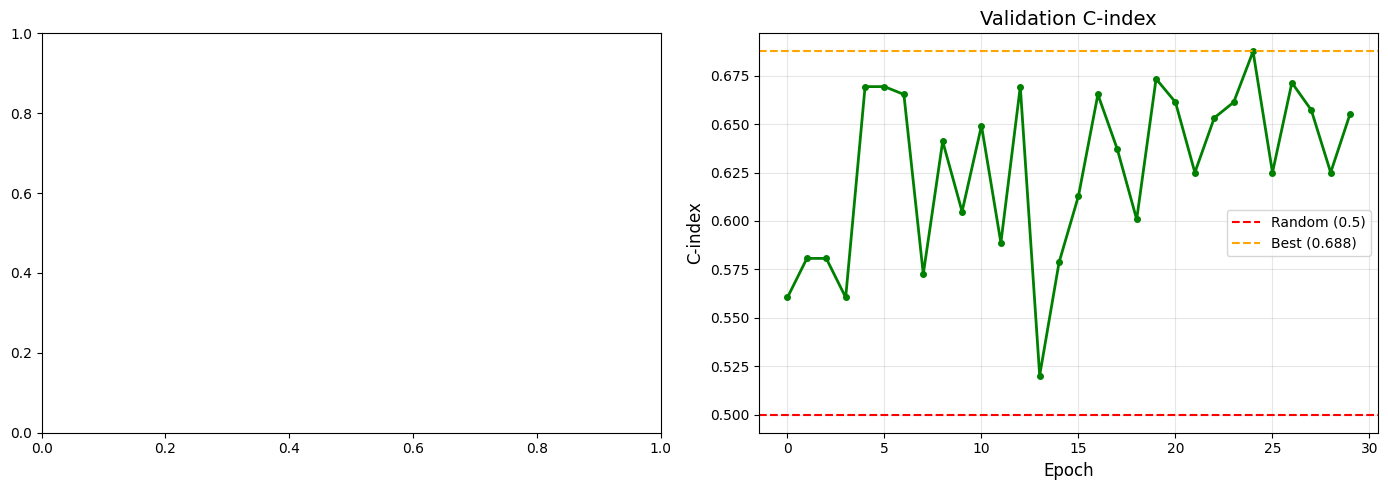

In [8]:
# Carica tutti i checkpoint per analizzare la progressione
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

checkpoint_dir = '/content/drive/MyDrive/checkpoints_fixed'
epochs = []
train_losses_history = []
val_c_indexes_history = []

# Se hai salvato la history durante training, usala
# Altrimenti ricarica dai checkpoint
for epoch in range(1, 31):  # assumendo 30 epochs
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pth")
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        epochs.append(epoch)
        val_c_indexes_history.append(checkpoint['c_index'])

best_c_index = max(val_c_indexes_history)
print(f"📈 Training Summary:")
print(f"Best C-index: {max(val_c_indexes_history):.4f} at epoch {np.argmax(val_c_indexes_history) + 1}")
print(f"Final C-index: {val_c_indexes_history[-1]:.4f}")
print(f"Improvement: {best_c_index - val_c_indexes_history[0]:.4f}")

# Plot più dettagliato
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# C-index
axes[1].plot(val_c_indexes_history, marker='o', linewidth=2, markersize=4, color='green')
axes[1].axhline(y=0.5, color='r', linestyle='--', label='Random (0.5)')
axes[1].axhline(y=best_c_index, color='orange', linestyle='--', label=f'Best ({best_c_index:.3f})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('C-index', fontsize=12)
axes[1].set_title('Validation C-index', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Carica il best model
best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
checkpoint = torch.load(best_model_path, weights_only=False)

model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=False).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation C-index: {checkpoint['c_index']:.4f}")

✅ Loaded best model from epoch 25
   Validation C-index: 0.6875


In [36]:
# Crea test loader


# Valuta
test_c_index, test_risks, test_times, test_events = evaluate_slice_level(
    model, test_loader, device
)

print(f"\n{'='*60}")
print(f"🎯 TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test C-index: {test_c_index:.4f}")
print(f"Number of patients: {len(test_risks)}")
print(f"Number of events: {sum(test_events)}")
print(f"Censoring rate: {1 - sum(test_events)/len(test_events):.2%}")

Dataset: 27 patients → 280 slices
📦 PatientBatchSampler: 27 patients, 3 patients/batch


Evaluating: 100%|██████████| 9/9 [02:59<00:00, 19.95s/it]

   Evaluated 27 patients
   Risk range: [-3.490, 3.330]

🎯 TEST SET RESULTS
Test C-index: 0.4962
Number of patients: 27
Number of events: 16.0
Censoring rate: 40.74%


TypeError: array type float16 is unsupported in linalg

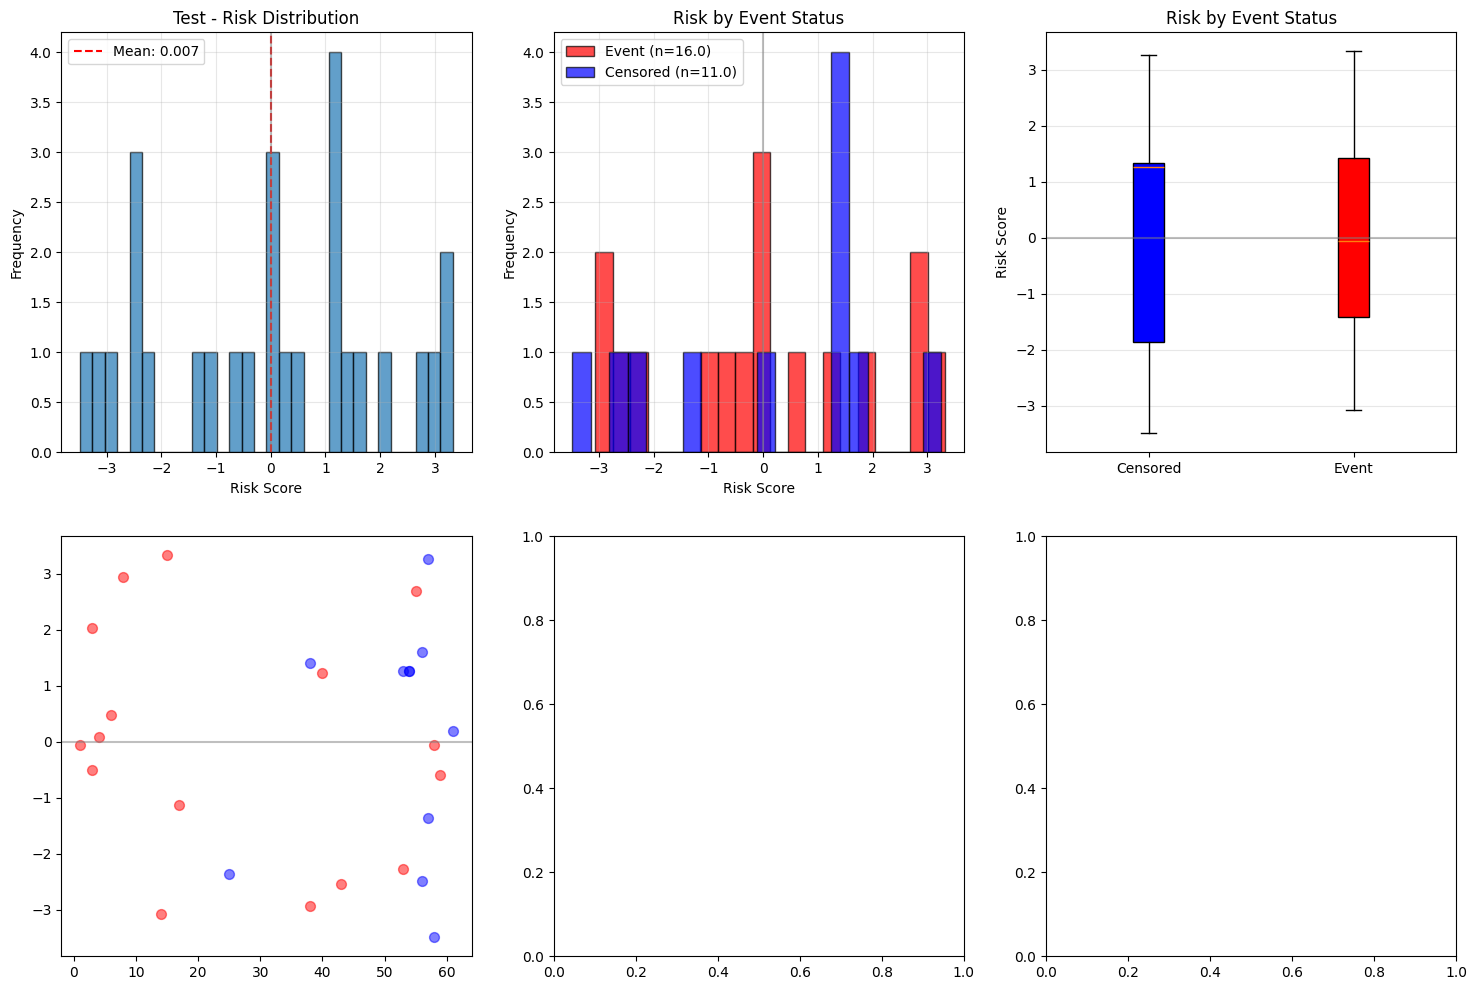

In [38]:
def comprehensive_risk_analysis(risks, times, events, dataset_name="Test"):
    """Analisi completa dei risk scores"""

    risks = np.array(risks)
    times = np.array(times)
    events = np.array(events)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Distribuzione generale
    axes[0, 0].hist(risks, bins=30, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(risks.mean(), color='r', linestyle='--',
                       label=f'Mean: {risks.mean():.3f}')
    axes[0, 0].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axes[0, 0].set_xlabel('Risk Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'{dataset_name} - Risk Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Distribuzione per evento
    axes[0, 1].hist(risks[events == 1], bins=20, alpha=0.7,
                    label=f'Event (n={sum(events)})', color='red', edgecolor='black')
    axes[0, 1].hist(risks[events == 0], bins=20, alpha=0.7,
                    label=f'Censored (n={len(events)-sum(events)})',
                    color='blue', edgecolor='black')
    axes[0, 1].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axes[0, 1].set_xlabel('Risk Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Risk by Event Status')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Boxplot per evento
    data_to_plot = [risks[events == 0], risks[events == 1]]
    bp = axes[0, 2].boxplot(data_to_plot, labels=['Censored', 'Event'],
                             patch_artist=True)
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    axes[0, 2].axhline(0, color='gray', linestyle='-', alpha=0.5)
    axes[0, 2].set_ylabel('Risk Score')
    axes[0, 2].set_title('Risk by Event Status')
    axes[0, 2].grid(axis='y', alpha=0.3)

    # 4. Risk vs Time (scatter)
    axes[1, 0].scatter(times[events == 0], risks[events == 0],
                       alpha=0.5, s=50, label='Censored', color='blue')
    axes[1, 0].scatter(times[events == 1], risks[events == 1],
                       alpha=0.5, s=50, label='Event', color='red')
    axes[1, 0].axhline(0, color='gray', linestyle='-', alpha=0.5)

    # Aggiungi linea di tendenza
    from scipy.stats import spearmanr
    corr, p_value = spearmanr(times, risks)
    z = np.polyfit(times, risks, 1)
    p = np.poly1d(z)
    axes[1, 0].plot(sorted(times), p(sorted(times)), "g--", alpha=0.5,
                    label=f'Trend (r={corr:.3f}, p={p_value:.3f})')

    axes[1, 0].set_xlabel('Survival Time (months)')
    axes[1, 0].set_ylabel('Risk Score')
    axes[1, 0].set_title('Risk vs Survival Time')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 5. Cumulative distribution
    risks_sorted = np.sort(risks)
    cumulative = np.arange(1, len(risks_sorted) + 1) / len(risks_sorted)
    axes[1, 1].plot(risks_sorted, cumulative, linewidth=2)
    axes[1, 1].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axes[1, 1].set_xlabel('Risk Score')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].set_title('Cumulative Distribution')
    axes[1, 1].grid(alpha=0.3)

    # 6. Statistiche per quartili
    quartiles = np.percentile(risks, [25, 50, 75])
    q1_mask = risks <= quartiles[0]
    q2_mask = (risks > quartiles[0]) & (risks <= quartiles[1])
    q3_mask = (risks > quartiles[1]) & (risks <= quartiles[2])
    q4_mask = risks > quartiles[2]

    event_rates = [
        events[q1_mask].mean(),
        events[q2_mask].mean(),
        events[q3_mask].mean(),
        events[q4_mask].mean()
    ]

    axes[1, 2].bar(['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'], event_rates,
                   color=['green', 'yellow', 'orange', 'red'], alpha=0.7,
                   edgecolor='black')
    axes[1, 2].set_ylabel('Event Rate')
    axes[1, 2].set_title('Event Rate by Risk Quartile')
    axes[1, 2].grid(axis='y', alpha=0.3)

    # Aggiungi valori sulle barre
    for i, v in enumerate(event_rates):
        axes[1, 2].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{dataset_name.lower()}_risk_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Stampa statistiche
    print(f"\n{'='*60}")
    print(f"📊 {dataset_name} Set - Detailed Statistics")
    print(f"{'='*60}")
    print(f"\nOverall Risk Statistics:")
    print(f"  Mean: {risks.mean():.4f}")
    print(f"  Std:  {risks.std():.4f}")
    print(f"  Min:  {risks.min():.4f}")
    print(f"  Max:  {risks.max():.4f}")
    print(f"  Median: {np.median(risks):.4f}")

    print(f"\nRisk by Event Status:")
    print(f"  Censored - Mean: {risks[events == 0].mean():.4f}, "
          f"Std: {risks[events == 0].std():.4f}")
    print(f"  Event    - Mean: {risks[events == 1].mean():.4f}, "
          f"Std: {risks[events == 1].std():.4f}")
    print(f"  Separation: {abs(risks[events == 1].mean() - risks[events == 0].mean()):.4f}")

    print(f"\nEvent Rates by Risk Quartile:")
    for i, (label, rate) in enumerate(zip(['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'], event_rates)):
        print(f"  {label}: {rate:.2%}")

    print(f"\nCorrelation with Survival Time:")
    corr, p_value = spearmanr(times, risks)
    print(f"  Spearman r: {corr:.4f} (p={p_value:.4f})")

    return risks, times, events

# Applica l'analisi
test_risks, test_times, test_events = comprehensive_risk_analysis(
    test_risks, test_times, test_events, dataset_name="Test"
)

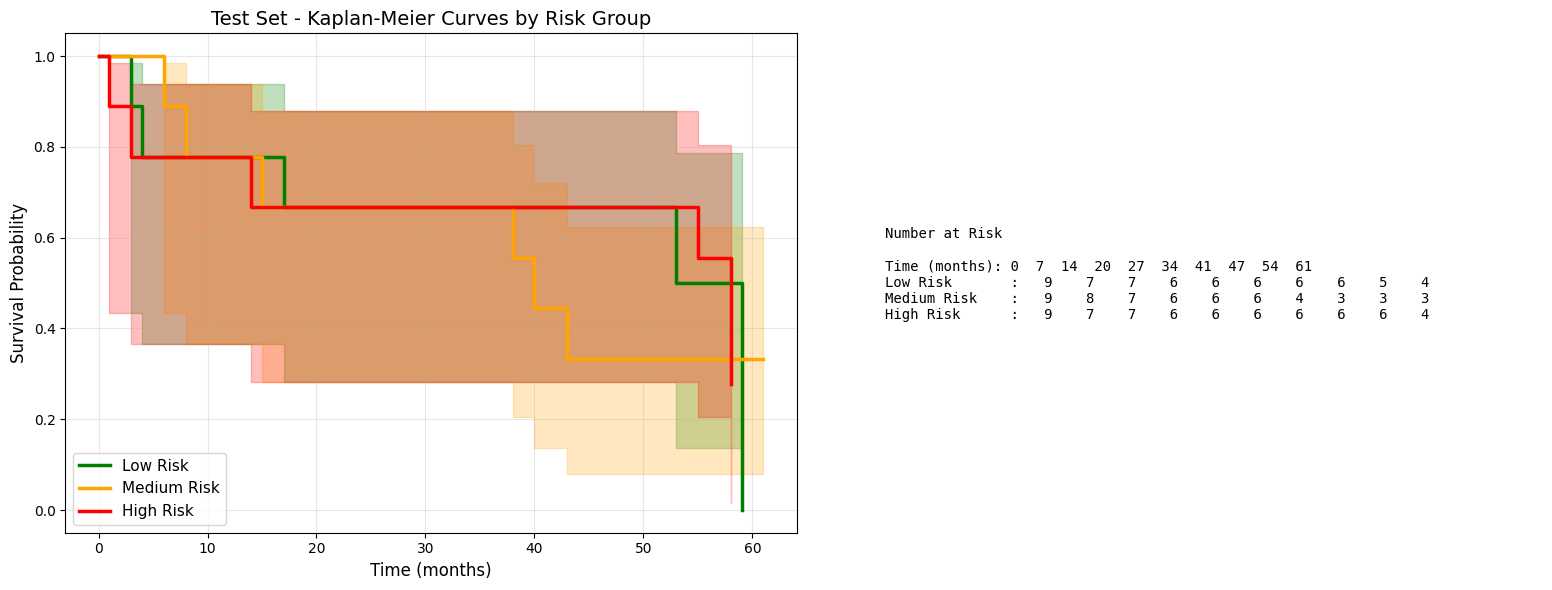


📊 Test Set - Survival Analysis

Pairwise Log-rank tests:
  Low Risk vs Medium Risk:
    P-value: 0.8165 ✗
  Low Risk vs High Risk:
    P-value: 0.9375 ✗
  Medium Risk vs High Risk:
    P-value: 0.5309 ✗

Median Survival Times:
  Low Risk: 53.0 months
  Medium Risk: 40.0 months
  High Risk: 58.0 months


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def plot_kaplan_meier_stratified(risks, times, events, n_groups=3, dataset_name="Test"):
    """Kaplan-Meier con test statistici"""

    risks = np.array(risks)
    times = np.array(times)
    events = np.array(events)

    # Dividi in gruppi
    if n_groups == 2:
        threshold = np.median(risks)
        groups = (risks > threshold).astype(int)
        labels = ['Low Risk', 'High Risk']
        colors = ['green', 'red']
    elif n_groups == 3:
        q33, q66 = np.percentile(risks, [33, 66])
        groups = np.digitize(risks, [q33, q66])
        labels = ['Low Risk', 'Medium Risk', 'High Risk']
        colors = ['green', 'orange', 'red']
    else:
        q25, q50, q75 = np.percentile(risks, [25, 50, 75])
        groups = np.digitize(risks, [q25, q50, q75])
        labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
        colors = ['green', 'blue', 'orange', 'red']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Kaplan-Meier curves
    kmf = KaplanMeierFitter()

    for i in range(n_groups):
        mask = groups == i
        kmf.fit(times[mask], events[mask], label=labels[i])
        kmf.plot_survival_function(ax=axes[0], color=colors[i], linewidth=2.5)

    axes[0].set_xlabel('Time (months)', fontsize=12)
    axes[0].set_ylabel('Survival Probability', fontsize=12)
    axes[0].set_title(f'{dataset_name} Set - Kaplan-Meier Curves by Risk Group', fontsize=14)
    axes[0].legend(fontsize=11, loc='best')
    axes[0].grid(alpha=0.3)

    # Plot 2: Number at risk table
    axes[1].axis('off')

    # Crea tabella
    time_points = np.linspace(0, times.max(), 10)
    table_data = []

    for i in range(n_groups):
        mask = groups == i
        n_at_risk = []
        for t in time_points:
            # Conta quanti sono ancora a rischio al tempo t
            at_risk = ((times[mask] >= t) | ((times[mask] < t) & (events[mask] == 0))).sum()
            n_at_risk.append(at_risk)
        table_data.append(n_at_risk)

    # Stampa tabella
    table_text = f"Number at Risk\n\n"
    table_text += "Time (months): " + "  ".join([f"{t:.0f}" for t in time_points]) + "\n"
    for i, (label, data) in enumerate(zip(labels, table_data)):
        table_text += f"{label:15s}: " + "  ".join([f"{n:3d}" for n in data]) + "\n"

    axes[1].text(0.1, 0.5, table_text, fontsize=10, family='monospace',
                 verticalalignment='center')

    plt.tight_layout()
    plt.savefig(f'{dataset_name.lower()}_kaplan_meier.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Log-rank test
    print(f"\n{'='*60}")
    print(f"📊 {dataset_name} Set - Survival Analysis")
    print(f"{'='*60}")

    # Pairwise log-rank tests
    if n_groups == 2:
        mask_low = groups == 0
        mask_high = groups == 1
        result = logrank_test(times[mask_low], times[mask_high],
                             events[mask_low], events[mask_high])
        print(f"\nLog-rank test (Low vs High):")
        print(f"  Test statistic: {result.test_statistic:.4f}")
        print(f"  P-value: {result.p_value:.4f}")
        print(f"  Significant: {'Yes ✓' if result.p_value < 0.05 else 'No ✗'}")
    else:
        print(f"\nPairwise Log-rank tests:")
        for i in range(n_groups):
            for j in range(i+1, n_groups):
                mask_i = groups == i
                mask_j = groups == j
                result = logrank_test(times[mask_i], times[mask_j],
                                     events[mask_i], events[mask_j])
                print(f"  {labels[i]} vs {labels[j]}:")
                print(f"    P-value: {result.p_value:.4f} "
                      f"{'✓' if result.p_value < 0.05 else '✗'}")

    # Median survival times
    print(f"\nMedian Survival Times:")
    for i in range(n_groups):
        mask = groups == i
        kmf.fit(times[mask], events[mask])
        median_surv = kmf.median_survival_time_
        print(f"  {labels[i]}: {median_surv:.1f} months")

    return groups, labels

# Applica
groups, labels = plot_kaplan_meier_stratified(
    test_risks, test_times, test_events, n_groups=3, dataset_name="Test"
)

In [ ]:
import numpy as np

print("\n🔍 Risk Score Analysis:")
print(f"\nCensored patients (vivi più a lungo):")
print(f"  Mean risk: {test_risks[test_events==0].mean():.4f}")
print(f"  Median risk: {np.median(test_risks[test_events==0]):.4f}")

print(f"\nEvent patients (morti):")
print(f"  Mean risk: {test_risks[test_events==1].mean():.4f}")
print(f"  Median risk: {np.median(test_risks[test_events==1]):.4f}")

print(f"\nDifference (Event - Censored): {test_risks[test_events==1].mean() - test_risks[test_events==0].mean():.4f}")

if test_risks[test_events==1].mean() > test_risks[test_events==0].mean():
    print("✅ Risk direction is CORRECT (higher risk = more events)")
else:
    print("❌ Risk direction is WRONG (higher risk = fewer events)")

In [ ]:
from scipy.stats import spearmanr

# Correlazione tra risk e tempo di sopravvivenza
corr, p_value = spearmanr(test_risks, test_times)

print(f"\n📊 Correlation Analysis:")
print(f"Spearman correlation (risk vs time): {corr:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation:")

if corr < -0.3 and p_value < 0.05:
    print("✅ GOOD: Higher risk → shorter survival (strong)")
elif corr < -0.1 and p_value < 0.05:
    print("⚠️ WEAK: Higher risk → shorter survival (weak)")
elif abs(corr) < 0.1 or p_value > 0.05:
    print("❌ BAD: No significant correlation")
elif corr > 0.1:
    print("❌ WRONG: Higher risk → LONGER survival (inverted!)")

Evaluating on all datasets...


Evaluating: 100%|██████████| 9/9 [02:38<00:00, 17.66s/it]



📊 FINAL RESULTS SUMMARY
Dataset         C-index      N Patients   N Events     Event Rate  
----------------------------------------------------------------------
Train           0.9056       121          73.0         60.33%      
Validation      0.7097       26           15.0         57.69%      
Test            0.5625       27           16.0         59.26%      


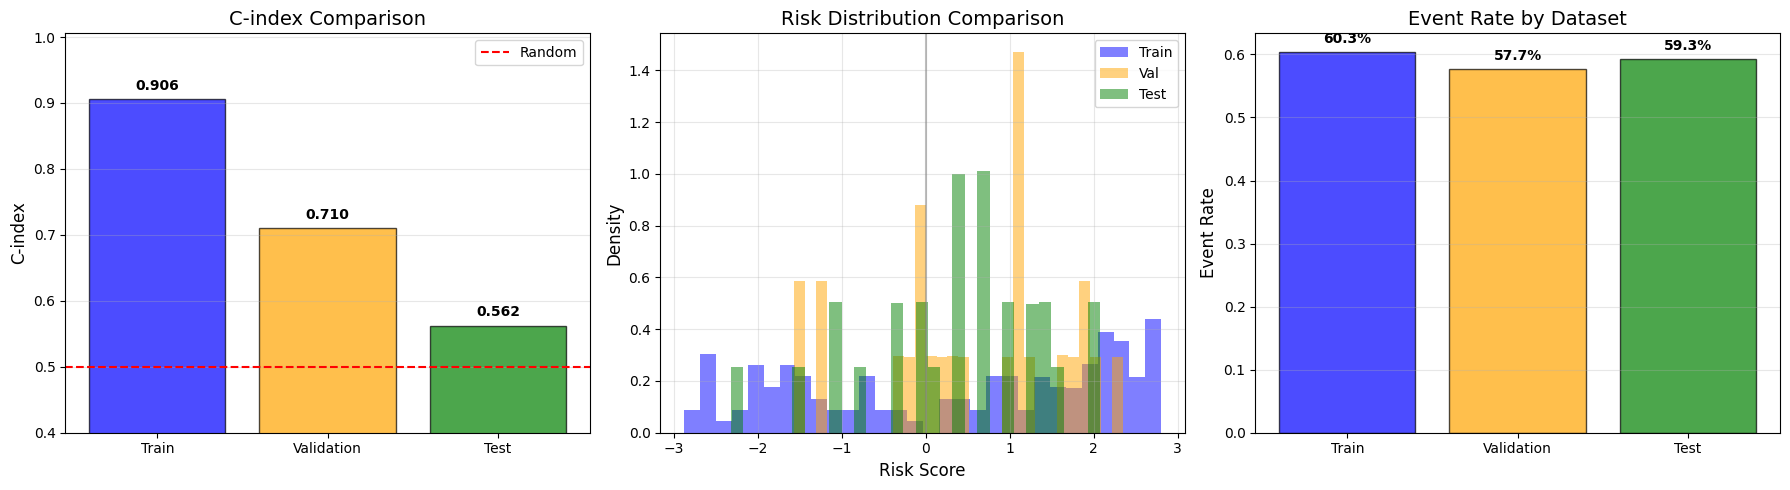

In [ ]:
def compare_datasets():
    """Confronta performance su tutti i dataset"""

    # Valuta su tutti i dataset
    print("Evaluating on all datasets...")

    train_c_index, train_risks, train_times, train_events = evaluate_slice_level(
        model, train_loader, device
    )
    val_c_index, val_risks, val_times, val_events = evaluate_slice_level(
        model, val_loader, device
    )
    test_c_index, test_risks, test_times, test_events = evaluate_slice_level(
        model, test_loader, device
    )

    # Tabella riassuntiva
    print(f"\n{'='*70}")
    print(f"📊 FINAL RESULTS SUMMARY")
    print(f"{'='*70}")
    print(f"{'Dataset':<15} {'C-index':<12} {'N Patients':<12} {'N Events':<12} {'Event Rate':<12}")
    print(f"{'-'*70}")
    print(f"{'Train':<15} {train_c_index:<12.4f} {len(train_risks):<12} "
          f"{sum(train_events):<12} {sum(train_events)/len(train_events):<12.2%}")
    print(f"{'Validation':<15} {val_c_index:<12.4f} {len(val_risks):<12} "
          f"{sum(val_events):<12} {sum(val_events)/len(val_events):<12.2%}")
    print(f"{'Test':<15} {test_c_index:<12.4f} {len(test_risks):<12} "
          f"{sum(test_events):<12} {sum(test_events)/len(test_events):<12.2%}")
    print(f"{'='*70}")

    # Plot comparativo
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    datasets = ['Train', 'Validation', 'Test']
    c_indexes = [train_c_index, val_c_index, test_c_index]
    colors_bar = ['blue', 'orange', 'green']

    # C-index comparison
    bars = axes[0].bar(datasets, c_indexes, color=colors_bar, alpha=0.7, edgecolor='black')
    axes[0].axhline(y=0.5, color='r', linestyle='--', label='Random')
    axes[0].set_ylabel('C-index', fontsize=12)
    axes[0].set_title('C-index Comparison', fontsize=14)
    axes[0].set_ylim([0.4, max(c_indexes) + 0.1])
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Aggiungi valori sopra le barre
    for bar, c in zip(bars, c_indexes):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{c:.3f}', ha='center', va='bottom', fontweight='bold')

    # Risk distribution comparison
    axes[1].hist(train_risks, bins=30, alpha=0.5, label='Train', color='blue', density=True)
    axes[1].hist(val_risks, bins=30, alpha=0.5, label='Val', color='orange', density=True)
    axes[1].hist(test_risks, bins=30, alpha=0.5, label='Test', color='green', density=True)
    axes[1].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axes[1].set_xlabel('Risk Score', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Risk Distribution Comparison', fontsize=14)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Event rate by dataset
    event_rates = [
        sum(train_events)/len(train_events),
        sum(val_events)/len(val_events),
        sum(test_events)/len(test_events)
    ]
    bars = axes[2].bar(datasets, event_rates, color=colors_bar, alpha=0.7, edgecolor='black')
    axes[2].set_ylabel('Event Rate', fontsize=12)
    axes[2].set_title('Event Rate by Dataset', fontsize=14)
    axes[2].grid(axis='y', alpha=0.3)

    for bar, rate in zip(bars, event_rates):
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

compare_datasets()

In [ ]:
import pandas as pd
import pickle

# Salva predizioni
predictions = {
    'test': {
        'patient_ids': test_df['Patient'].unique().tolist(),
        'risks': test_risks,
        'times': test_times,
        'events': test_events,
        'c_index': test_c_index
    }
}

# Salva come pickle
with open('final_predictions.pkl', 'wb') as f:
    pickle.dump(predictions, f)

# Salva come CSV
results_df = pd.DataFrame({
    'risk_score': test_risks,
    'survival_time': test_times,
    'event': test_events
})
results_df.to_csv('test_predictions.csv', index=False)

print("✅ Results saved!")
print(f"   - final_predictions.pkl")
print(f"   - test_predictions.csv")

✅ Results saved!
   - final_predictions.pkl
   - test_predictions.csv
